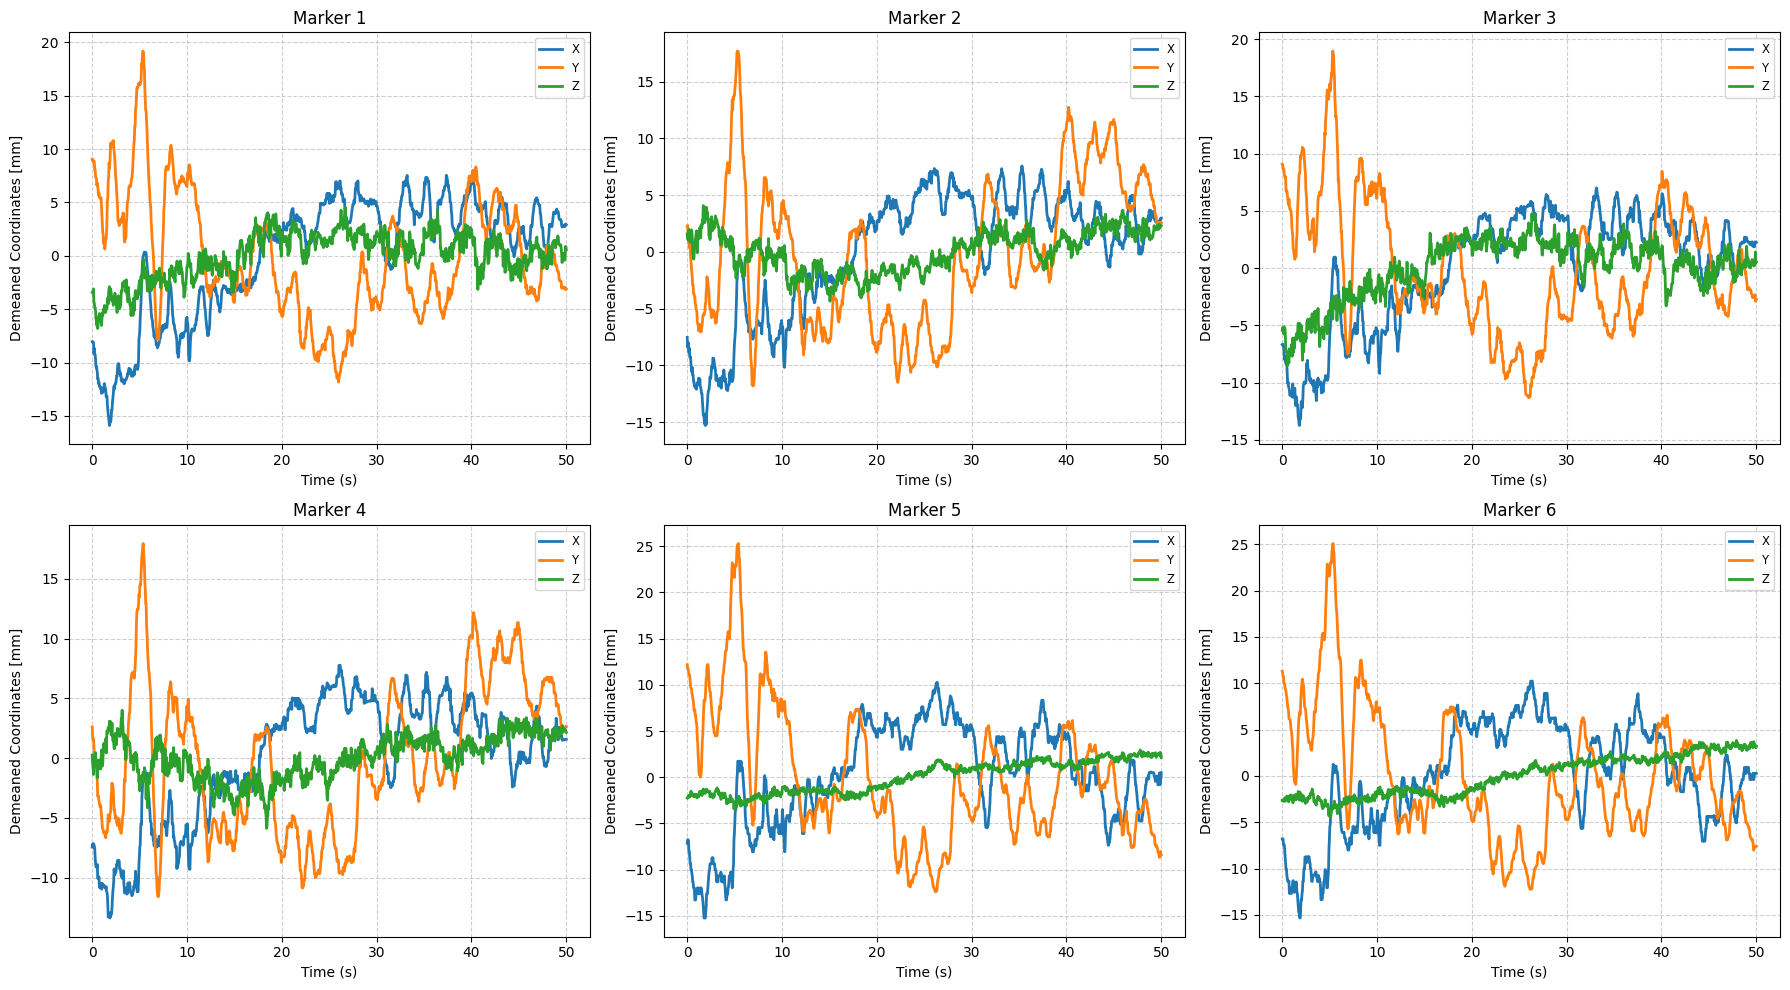

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

input_csv = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/mariona4/Output_processed/transform_3d.csv"
output_folder = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/mariona4/Output_processed"

os.makedirs(output_folder, exist_ok=True)

# -------------------------
# PLOTTING FUNCTION
# -------------------------
def plot_to_ax(ax, data, marker_pos):
    num_points = data.shape[0]
    t = np.linspace(0, 50, num_points)  # time axis (0–60 sec)

    ax.plot(t, data[:, 0], label='X', linewidth=2)
    ax.plot(t, data[:, 1], label='Y', linewidth=2)
    ax.plot(t, data[:, 2], label='Z', linewidth=2)

    ax.set_ylabel('Demeaned Coordinates [mm]')
    ax.set_xlabel('Time (s)')
    ax.set_title(marker_pos)
    ax.legend(loc='upper right', fontsize='small')
    ax.grid(True, linestyle='--', alpha=0.6)


# -------------------------
# LOAD DATA
# -------------------------

raw_df = pd.read_csv(input_csv)
raw_df = raw_df.iloc[20:-20].reset_index(drop=True) # optional: cut beggining and end frames

marker1 = raw_df[['pt1_x', 'pt1_y', 'pt1_z']]
marker2 = raw_df[['pt2_x', 'pt2_y', 'pt2_z']]
marker3 = raw_df[['pt3_x', 'pt3_y', 'pt3_z']]
marker4 = raw_df[['pt4_x', 'pt4_y', 'pt4_z']]
marker5 = raw_df[['pt5_x', 'pt5_y', 'pt5_z']]
marker6 = raw_df[['pt6_x', 'pt6_y', 'pt6_z']]

markers = [
    (marker1, 'Marker 1', 'pt1'),
    (marker2, 'Marker 2', 'pt2'),
    (marker3, 'Marker 3', 'pt3'),
    (marker4, 'Marker 4', 'pt4'),
    (marker5, 'Marker 5', 'pt5'),
    (marker6, 'Marker 6', 'pt6')
]

# -------------------------
# CREATE SUBPLOTS (2 rows, 3 columns for 6 markers)
# -------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (df, name, prefix) in zip(axes, markers):
    x = df[f'{prefix}_x']
    y = df[f'{prefix}_y']
    z = df[f'{prefix}_z']

    x_norm = x - x.mean()
    y_norm = y - y.mean()
    z_norm = z - z.mean()

    data = np.vstack((x_norm, y_norm, z_norm)).T

    plot_to_ax(ax, data, name)

plt.tight_layout()
save_path = os.path.join(output_folder, 'markers_normalized.png')
plt.savefig(save_path, dpi=200)
plt.show()

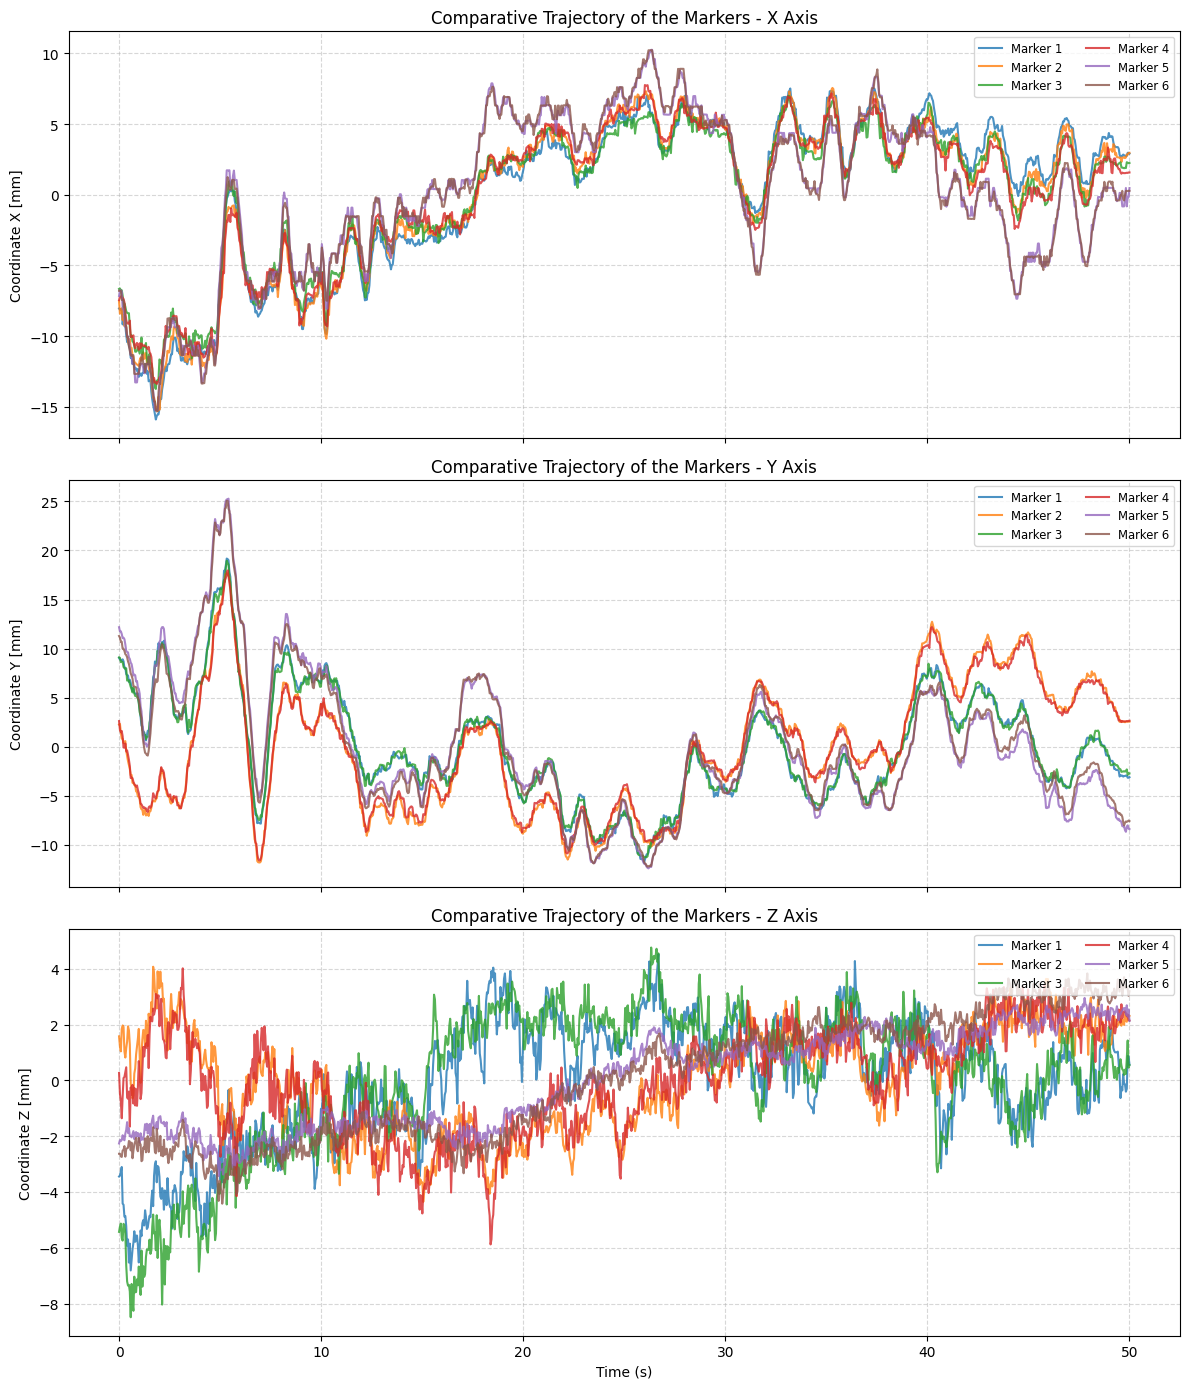

In [23]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

input_csv = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/mariona4/Output_processed/transform_3d.csv"
output_folder = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/mariona4/Output_processed"

os.makedirs(output_folder, exist_ok=True)

# -------------------------
# LOAD DATA
# -------------------------
raw_df = pd.read_csv(input_csv)
raw_df = raw_df.iloc[20:-20].reset_index(drop=True)

num_points = raw_df.shape[0]
t = np.linspace(0, 50, num_points)

marker_prefixes = ["pt1", "pt2", "pt3", "pt4", "pt5", "pt6"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]

# -------------------------
# CREATE SUBPLOTS
# -------------------------
fig, axes = plt.subplots(3, 1, figsize=(12, 14), sharex=True)
axes_names = ["X", "Y", "Z"]

for i, axis_letter in enumerate(["x", "y", "z"]):
    ax = axes[i]

    for j, prefix in enumerate(marker_prefixes):
        coord = raw_df[f"{prefix}_{axis_letter}"]

        # Normalization
        coord_norm = coord - coord.mean()

        ax.plot(
            t,
            coord_norm,
            label=f"Marker {j+1}",
            color=colors[j],
            linewidth=1.5,
            alpha=0.8,
        )

    ax.set_ylabel(f"Coordinate {axes_names[i]} [mm]")
    ax.set_title(
        f"Comparative Trajectory of the Markers - {axes_names[i]} Axis"
    )
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(loc="upper right", fontsize="small", ncol=2)

axes[-1].set_xlabel("Time (s)")

plt.tight_layout()

save_path = os.path.join(output_folder, "trajectories_comparativa.png")
plt.savefig(save_path, dpi=200)
plt.show()

In [24]:
import numpy as np
import pandas as pd

input_csv = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/mariona4/Output_processed/transform_3d.csv"

df_motion_raw = pd.read_csv(input_csv)
df_motion = df_motion_raw.iloc[20:-20].reset_index(drop=True)

marker_prefixes = ["pt1", "pt2", "pt3", "pt4" , "pt5", "pt6"]
axes = ["x", "y", "z"]
results = []

# -------------------------
# CÀLCUL DE MÈTRIQUES
# -------------------------
for j, prefix in enumerate(marker_prefixes):
    for axis in axes:
        motion_coord = df_motion[f"{prefix}_{axis}"]
        ideal_pos = motion_coord.mean()
        std_dev = motion_coord.std()
        rmse = np.sqrt(np.mean((motion_coord - ideal_pos) ** 2))
        peak_to_peak = motion_coord.max() - motion_coord.min()
        results.append({
            "Marker": f"Marker {j+1}",
            "Axis": axis.upper(),
            "Std Dev (σ) [mm]": round(std_dev, 4),
            "Peak-to-Peak [mm]": round(peak_to_peak, 4)
        })

metrics_df = pd.DataFrame(results)

print(metrics_df.to_string(index=False))


  Marker Axis  Std Dev (σ) [mm]  Peak-to-Peak [mm]
Marker 1    X            5.5924            23.4384
Marker 1    Y            5.6467            31.0071
Marker 1    Z            2.1646            11.3321
Marker 2    X            5.4591            22.8661
Marker 2    Y            6.4168            29.4875
Marker 2    Z            1.8002             8.4250
Marker 3    X            4.8971            20.7433
Marker 3    Y            5.5153            30.2597
Marker 3    Z            2.5819            13.2465
Marker 4    X            5.1184            21.1504
Marker 4    Y            6.1411            29.5611
Marker 4    Z            1.8185             9.8923
Marker 5    X            5.5795            25.4876
Marker 5    Y            7.0195            37.6839
Marker 5    Z            1.6981             6.3806
Marker 6    X            5.5975            25.5603
Marker 6    Y            6.7959            37.2937
Marker 6    Z            2.1590             8.2499


In [25]:
import numpy as np
import pandas as pd

input_csv = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/mariona4/Output_processed/transform_3d.csv"

df_motion_raw = pd.read_csv(input_csv)
df_motion = df_motion_raw.iloc[20:-20].reset_index(drop=True)

marker_prefixes = ["pt1", "pt2", "pt3", "pt4", "pt5", "pt6"]
axes = ["x", "y", "z"]
results = []

for j, prefix in enumerate(marker_prefixes):
    for axis in axes:
        signal = df_motion[f"{prefix}_{axis}"].dropna()

        std_dev = signal.std()
        peak_to_peak = signal.max() - signal.min()

        # More robust than raw peak-to-peak: range between 2.5th and 97.5th percentile
        p975 = np.percentile(signal, 97.5)
        p025 = np.percentile(signal, 2.5)
        robust_range = p975 - p025

        results.append({
            "Marker": f"Marker {j+1}",
            "Axis": axis.upper(),
            "Std Dev (σ) [mm]": round(std_dev, 4),
            "Peak-to-Peak [mm]": round(peak_to_peak, 4),
        })

metrics_df = pd.DataFrame(results)
print(metrics_df.to_string(index=False))


  Marker Axis  Std Dev (σ) [mm]  Peak-to-Peak [mm]
Marker 1    X            5.5924            23.4384
Marker 1    Y            5.6467            31.0071
Marker 1    Z            2.1646            11.3321
Marker 2    X            5.4591            22.8661
Marker 2    Y            6.4168            29.4875
Marker 2    Z            1.8002             8.4250
Marker 3    X            4.8971            20.7433
Marker 3    Y            5.5153            30.2597
Marker 3    Z            2.5819            13.2465
Marker 4    X            5.1184            21.1504
Marker 4    Y            6.1411            29.5611
Marker 4    Z            1.8185             9.8923
Marker 5    X            5.5795            25.4876
Marker 5    Y            7.0195            37.6839
Marker 5    Z            1.6981             6.3806
Marker 6    X            5.5975            25.5603
Marker 6    Y            6.7959            37.2937
Marker 6    Z            2.1590             8.2499


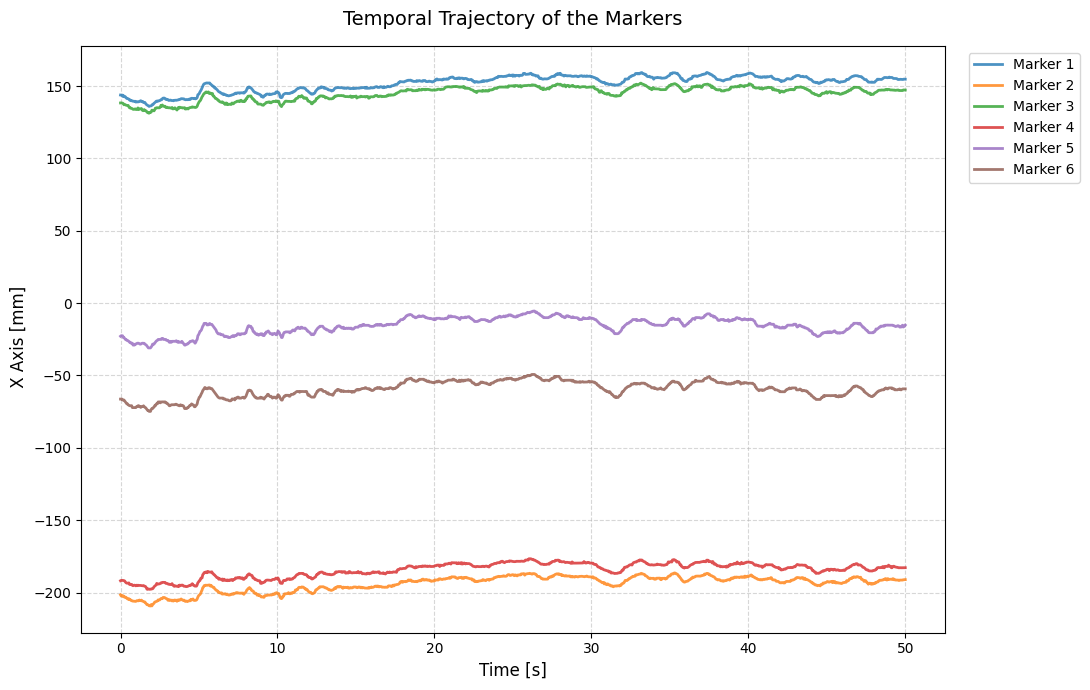

In [26]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

input_csv = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/mariona4/Output_processed/transform_3d.csv"
output_folder = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/mariona4/Output_processed"

os.makedirs(output_folder, exist_ok=True)

# -------------------------
# LOAD DATA
# -------------------------
raw_df = pd.read_csv(input_csv)
raw_df = raw_df.iloc[20:-20].reset_index(drop=True)

num_points = raw_df.shape[0]
t = np.linspace(0, 50, num_points)
marker_prefixes = ["pt1", "pt2", "pt3", "pt4", "pt5", "pt6"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]

# -------------------------
# CREATE PLOT
# -------------------------
fig, ax = plt.subplots(figsize=(11, 7))

for j, prefix in enumerate(marker_prefixes):
    x_coords = raw_df[f"{prefix}_x"]
    ax.plot(t, x_coords, label=f"Marker {j+1}", color=colors[j], linewidth=2, alpha=0.8,)


ax.set_xlabel("Time [s]", fontsize=12)
ax.set_ylabel(" X Axis [mm]", fontsize=12)
ax.set_title( "Temporal Trajectory of the Markers", fontsize=14, pad=15)

ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize="medium")

plt.tight_layout()

plt.savefig(save_path, dpi=200)
plt.show()

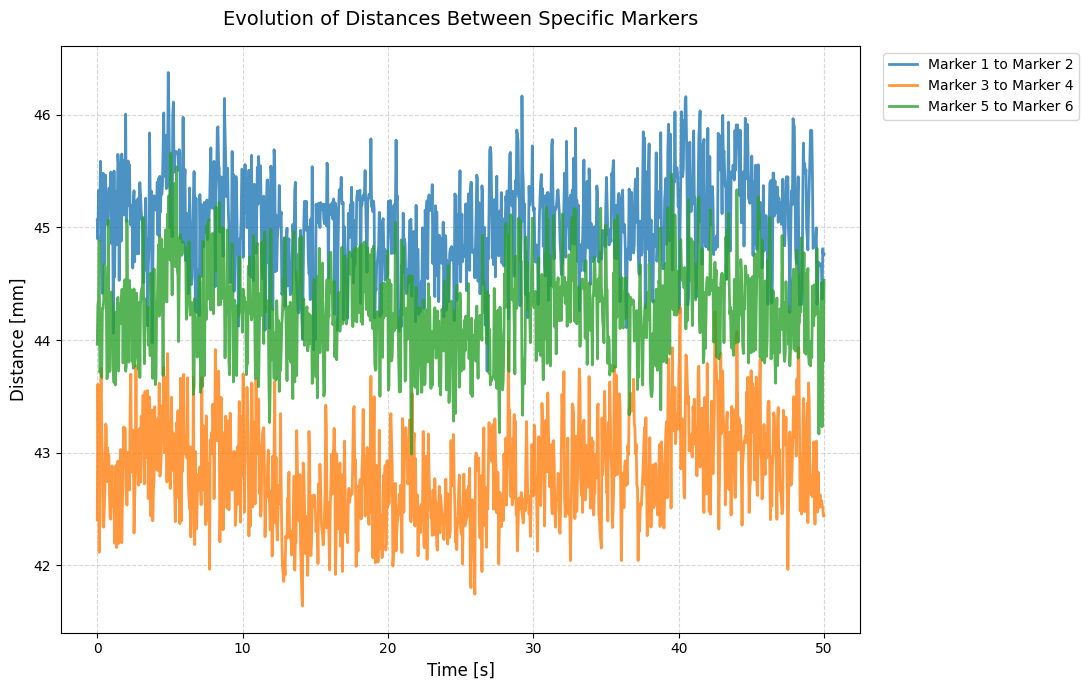

In [28]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

input_csv = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/mariona4/Output_processed/transform_3d.csv"
output_folder = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/mariona4/Output_processed"

os.makedirs(output_folder, exist_ok=True)

# -------------------------
# LOAD DATA
# -------------------------
raw_df = pd.read_csv(input_csv)
raw_df = raw_df.iloc[20:-20].reset_index(drop=True)

num_points = raw_df.shape[0]
t = np.linspace(0, 50, num_points)

# Function to calculate 3D Euclidean distance between two markers
def calculate_distance(df, marker_a, marker_b):
    dx = df[f"{marker_a}_x"] - df[f"{marker_b}_x"]
    dy = df[f"{marker_a}_y"] - df[f"{marker_b}_y"]
    dz = df[f"{marker_a}_z"] - df[f"{marker_b}_z"]
    return np.sqrt(dx ** 2 + dy ** 2 + dz ** 2)

# -------------------------
# CALCULATE DISTANCES
# -------------------------
dist_1_2 = calculate_distance(raw_df, "pt1", "pt3")
dist_3_6 = calculate_distance(raw_df, "pt2", "pt4")
dist_4_5 = calculate_distance(raw_df, "pt5", "pt6")

# -------------------------
# CREATE PLOT
# -------------------------
fig, ax = plt.subplots(figsize=(11, 7))

ax.plot(t, dist_1_2, label="Marker 1 to Marker 2", color="#1f77b4", linewidth=2, alpha=0.8)
ax.plot(t, dist_3_6, label="Marker 3 to Marker 4", color="#ff7f0e", linewidth=2, alpha=0.8)
ax.plot(t, dist_4_5, label="Marker 5 to Marker 6", color="#2ca02c", linewidth=2, alpha=0.8)

ax.set_xlabel("Time [s]", fontsize=12)
ax.set_ylabel("Distance [mm]", fontsize=12)
ax.set_title("Evolution of Distances Between Specific Markers", fontsize=14, pad=15)

ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize="medium")

plt.tight_layout()
plt.savefig(save_path, dpi=200)
plt.show()

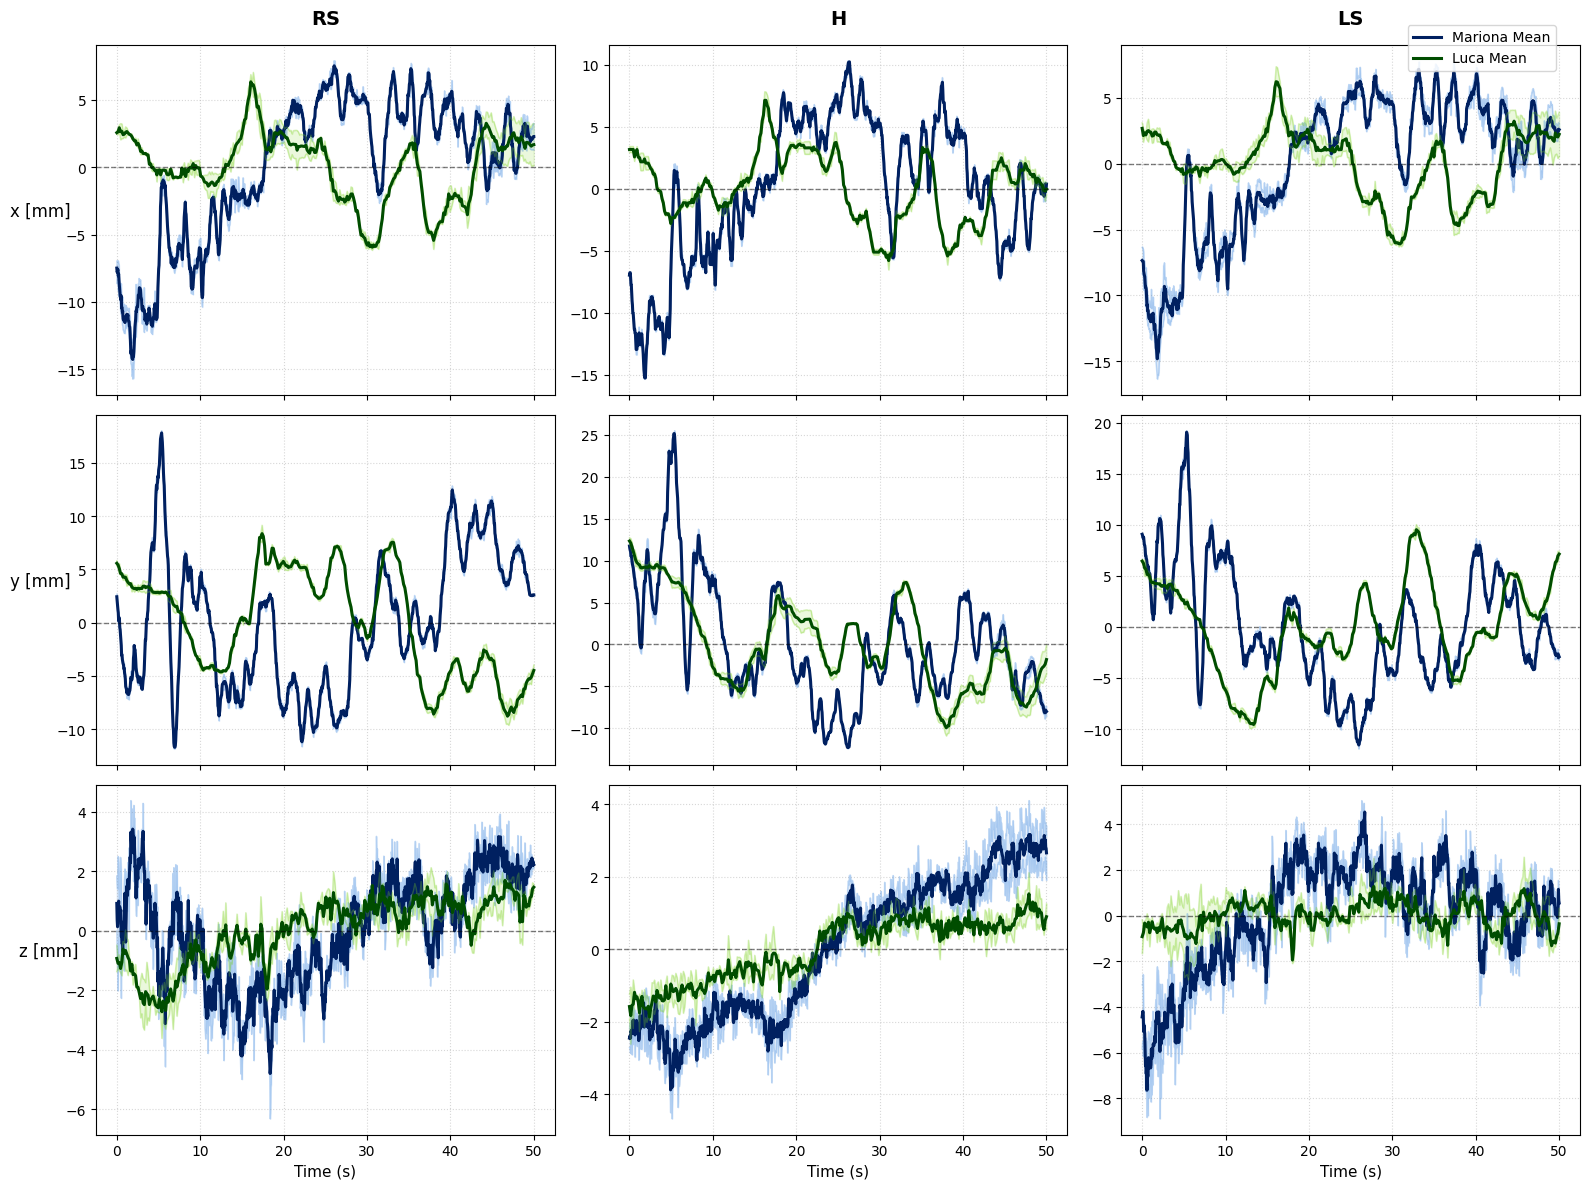

In [29]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

mariona_csv = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/mariona4/Output_processed/transform_3d.csv"
luca_csv = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/luca4/Output_processed/transform_3d.csv"

output_folder = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/mariona4/Output_processed"
os.makedirs(output_folder, exist_ok=True)

# -------------------------
# DEFINE SPECIFIC MARKER CONFIGURATIONS
# -------------------------
mariona_pairs = {
    "LS": ("pt1", "pt3"),
    "RS": ("pt2", "pt4"),
    "H":  ("pt5", "pt6")
}

luca_pairs = {
    "LS": ("pt1", "pt3"),
    "RS": ("pt2", "pt4"),
    "H":  ("pt5", "pt6")
}

# -------------------------
# HELPER FUNCTION FOR CALCULATIONS
# -------------------------
def process_recording_data(csv_path, pairs_dict):
    df = pd.read_csv(csv_path)
    df = df.iloc[20:-20].reset_index(drop=True)

    num_points = df.shape[0]
    t_axis = np.linspace(0, 50, num_points)

    results = {}
    axes_letters = ["x", "y", "z"]

    for part, (m1, m2) in pairs_dict.items():
        results[part] = {}
        for axis in axes_letters:
            coord1 = df[f"{m1}_{axis}"]
            coord2 = df[f"{m2}_{axis}"]

            # Center data around 0
            coord1_norm = coord1 - coord1.mean()
            coord2_norm = coord2 - coord2.mean()

            mean_profile = (coord1_norm + coord2_norm) / 2
            std_profile = np.std([coord1_norm, coord2_norm], axis=0, ddof=1)

            results[part][axis] = {
                "mean": mean_profile,
                "std": std_profile
            }

    return t_axis, results

t_mariona, mariona_data = process_recording_data(mariona_csv, mariona_pairs)
t_luca, luca_data = process_recording_data(luca_csv, luca_pairs)

# -------------------------
# PLOT GRID
# -------------------------
fig, axes = plt.subplots(3, 3, figsize=(16, 12), sharex=True)

part_keys = ["RS", "H", "LS"]
axes_letters = ["x", "y", "z"]

mariona_mean_color = "#002060"
mariona_std_color = "#4a90e2"
luca_mean_color = "#004d00"
luca_std_color = "#7ed321"

for row_idx, axis_letter in enumerate(axes_letters):
    for col_idx, part in enumerate(part_keys):
        ax = axes[row_idx, col_idx]

        # 1. PLOT MARIONA1 DATA
        m_stats = mariona_data[part][axis_letter]
        m_mean = m_stats["mean"]
        m_std = m_stats["std"]

        m_upper = m_mean + m_std
        m_lower = m_mean - m_std

        # Error bounds and fill
        ax.plot(t_mariona, m_upper, color=mariona_std_color, alpha=0.3, linewidth=1)
        ax.plot(t_mariona, m_lower, color=mariona_std_color, alpha=0.3, linewidth=1)
        ax.fill_between(t_mariona, m_lower, m_upper, color=mariona_std_color, alpha=0.15)

        # Mean profile line
        ax.plot(
            t_mariona, m_mean,
            color=mariona_mean_color, linewidth=2.2,
            label="Mariona Mean" if (row_idx == 0 and col_idx == 0) else ""
        )

        # 2. OVERLAY LUCA1 DATA
        l_stats = luca_data[part][axis_letter]
        l_mean = l_stats["mean"]
        l_std = l_stats["std"]

        l_upper = l_mean + l_std
        l_lower = l_mean - l_std

        # Error bounds and fill
        ax.plot(t_luca, l_upper, color=luca_std_color, alpha=0.3, linewidth=1)
        ax.plot(t_luca, l_lower, color=luca_std_color, alpha=0.3, linewidth=1)
        ax.fill_between(t_luca, l_lower, l_upper, color=luca_std_color, alpha=0.15)

        # Mean profile line
        ax.plot(
            t_luca, l_mean,
            color=luca_mean_color, linewidth=2.2,
            label="Luca Mean" if (row_idx == 0 and col_idx == 0) else ""
        )

        ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.5)

        if row_idx == 0:
            ax.set_title(part, fontsize=14, fontweight="bold", pad=15)

        if col_idx == 0:
            ax.set_ylabel(f"{axis_letter} [mm]", fontsize=12, labelpad=12, rotation=0)

        ax.grid(True, linestyle=":", alpha=0.5)

# Label shared timeline
for ax in axes[-1, :]:
    ax.set_xlabel("Time (s)", fontsize=11)

# Combined legend position
fig.legend(loc="upper right", bbox_to_anchor=(0.98, 0.98), fontsize="medium")

plt.tight_layout()

# Save final overlay image matrix
save_path = os.path.join(output_folder, "motion_profiles_overlay_final.png")
plt.savefig(save_path, dpi=200)
plt.show()

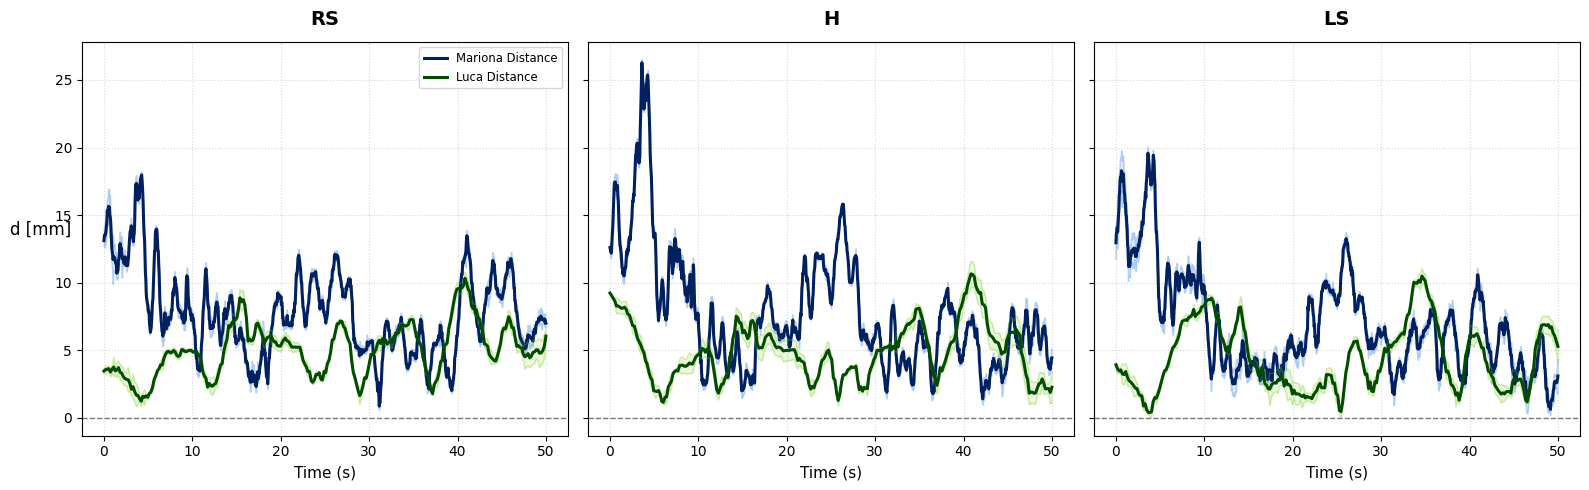

In [30]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

mariona_csv = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/mariona4/Output_processed/transform_3d.csv"
luca_csv = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/luca4/Output_processed/transform_3d.csv"

output_folder = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/r/Output_processed"
os.makedirs(output_folder, exist_ok=True)

# -------------------------
# DEFINE SPECIFIC MARKER CONFIGURATIONS
# -------------------------
mariona_pairs = {
    "LS": ("pt1", "pt3"),
    "RS": ("pt2", "pt4"),
    "H":  ("pt5", "pt6")
}

luca_pairs = {
    "LS": ("pt1", "pt3"),
    "RS": ("pt4", "pt2"),
    "H":  ("pt5", "pt6")
}

# -------------------------
# HELPER FUNCTION FOR METRICS
# -------------------------
def process_euclidean_metrics(csv_path, pairs_dict):
    df = pd.read_csv(csv_path)
    df = df.iloc[50:-50].reset_index(drop=True)

    num_points = df.shape[0]
    t_axis = np.linspace(0, 50, num_points)

    results = {}
    axes_letters = ["x", "y", "z"]

    for part, (m1, m2) in pairs_dict.items():
        # 1. Compute normalized mean and std for each axis
        motion_data = {}
        for axis in axes_letters:
            coord1 = df[f"{m1}_{axis}"]
            coord2 = df[f"{m2}_{axis}"]

            coord1_norm = coord1 - coord1.mean()
            coord2_norm = coord2 - coord2.mean()

            motion_data[f"{axis}_mean"] = (coord1_norm + coord2_norm) / 2
            motion_data[f"{axis}_std"] = np.std([coord1_norm, coord2_norm], axis=0, ddof=1)

        # 2. Compute Euclidean Distance (d) from origin
        x = motion_data["x_mean"]
        y = motion_data["y_mean"]
        z = motion_data["z_mean"]

        d = np.sqrt(x**2 + y**2 + z**2)

        # 3. Propagate Standard Deviation (sigma_d)
        sig_x = motion_data["x_std"]
        sig_y = motion_data["y_std"]
        sig_z = motion_data["z_std"]

        # To avoid potential division by zero if d is exactly 0
        safe_d = np.where(d == 0, 1e-6, d)

        sigma_d = np.sqrt((x * sig_x)**2 + (y * sig_y)**2 + (z * sig_z)**2) / safe_d

        results[part] = {
            "d": d,
            "sigma_d": sigma_d
        }

    return t_axis, results

# Process metrics for both participants
t_mariona, mariona_dist = process_euclidean_metrics(mariona_csv, mariona_pairs)
t_luca, luca_dist = process_euclidean_metrics(luca_csv, luca_pairs)

# -------------------------
# PLOT DISTANCES (1x3 Row Layout)
# -------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
part_keys = ["RS", "H", "LS"]

# Style color palette
mariona_mean_color = "#002060"
mariona_std_color = "#4a90e2"
luca_mean_color = "#004d00"
luca_std_color = "#7ed321"

for idx, part in enumerate(part_keys):
    ax = axes[idx]

    # --- Plot Mariona ---
    m_d = mariona_dist[part]["d"]
    m_sig = mariona_dist[part]["sigma_d"]

    m_upper = m_d + m_sig
    m_lower = np.maximum(0, m_d - m_sig)  # Distance cannot drop below absolute zero

    ax.plot(t_mariona, m_upper, color=mariona_std_color, alpha=0.3, linewidth=1)
    ax.plot(t_mariona, m_lower, color=mariona_std_color, alpha=0.3, linewidth=1)
    ax.fill_between(t_mariona, m_lower, m_upper, color=mariona_std_color, alpha=0.15)
    ax.plot(t_mariona, m_d, color=mariona_mean_color, linewidth=2.2, label="Mariona Distance")

    # --- Plot Luca ---
    l_d = luca_dist[part]["d"]
    l_sig = luca_dist[part]["sigma_d"]

    l_upper = l_d + l_sig
    l_lower = np.maximum(0, l_d - l_sig)

    ax.plot(t_luca, l_upper, color=luca_std_color, alpha=0.3, linewidth=1)
    ax.plot(t_luca, l_lower, color=luca_std_color, alpha=0.3, linewidth=1)
    ax.fill_between(t_luca, l_lower, l_upper, color=luca_std_color, alpha=0.15)
    ax.plot(t_luca, l_d, color=luca_mean_color, linewidth=2.2, label="Luca Distance")

    # --- Custom Plot Styling ---
    ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.5)
    ax.set_title(part, fontsize=14, fontweight="bold", pad=12)
    ax.set_xlabel("Time (s)", fontsize=11)
    ax.grid(True, linestyle=":", alpha=0.5)

    if idx == 0:
        ax.set_ylabel("d [mm]", fontsize=12, labelpad=10, rotation=0)

# Single unified legend
axes[0].legend(loc="upper right", fontsize="small")

plt.tight_layout()

plt.savefig(save_path, dpi=200)
plt.show()

In [31]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

mariona_csv = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/mariona4/Output_processed/transform_3d.csv"
luca_csv = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/luca4/Output_processed/transform_3d.csv"

output_folder = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/r/Output_processed"
os.makedirs(output_folder, exist_ok=True)

# -------------------------
# DEFINE SPECIFIC MARKER CONFIGURATIONS
# -------------------------
mariona_pairs = {
    "LS": ("pt1", "pt3"),
    "RS": ("pt2", "pt4"),
    "H":  ("pt5", "pt6")
}

luca_pairs = {
    "LS": ("pt1", "pt3"),
    "RS": ("pt4", "pt2"),
    "H":  ("pt5", "pt6")
}

# -------------------------
# HELPER FUNCTION FOR EXTRACTION
# -------------------------
def process_recording_data(csv_path, pairs_dict):
    df = pd.read_csv(csv_path)
    df = df.iloc[50:-50].reset_index(drop=True)

    results = {}
    axes_letters = ["x", "y", "z"]

    for part, (m1, m2) in pairs_dict.items():
        results[part] = {}
        for axis in axes_letters:
            coord1 = df[f"{m1}_{axis}"]
            coord2 = df[f"{m2}_{axis}"]

            # Center data around 0
            coord1_norm = coord1 - coord1.mean()
            coord2_norm = coord2 - coord2.mean()

            # The standard deviation profile represents the error (d_t) at each time frame
            std_profile = np.std([coord1_norm, coord2_norm], axis=0, ddof=1)

            results[part][axis] = std_profile

    return results

# -------------------------
# METRIC CALCULATION FUNCTION
# -------------------------
def calculate_metrics(data_dict):
    """
    Calculates overall MAE and RMSE across all time steps (N) and all 3 spatial axes
    for each anatomical position.
    """
    metrics_summary = {}

    for part, axes_data in data_dict.items():
        # Combine all standard deviation values (d_t) across x, y, and z axes into one flat array
        all_d_t = np.concatenate([axes_data["x"], axes_data["y"], axes_data["z"]])

        # Calculate MAE: Mean of absolute values (since d_t is std, it's already positive)
        mae_val = np.mean(np.abs(all_d_t))

        # Calculate RMSE: Square root of the mean of squared values
        rmse_val = np.sqrt(np.mean(all_d_t**2))

        metrics_summary[part] = {
            "MAE": mae_val,
            "RMSE": rmse_val
        }

    return metrics_summary

# -------------------------
# EXECUTION & DATA PROCESSING
# -------------------------
# Extract profiles
mariona_profiles = process_recording_data(mariona_csv, mariona_pairs)
luca_profiles = process_recording_data(luca_csv, luca_pairs)

# Compute MAE and RMSE
mariona_metrics = calculate_metrics(mariona_profiles)
luca_metrics = calculate_metrics(luca_profiles)

# -------------------------
# COMPILE AND SAVE RESULTS
# -------------------------
rows = []
for part in ["RS", "H", "LS"]:
    rows.append({
        "Volunteer": "Mariona",
        "Anatomical Position": part,
        "MAE": mariona_metrics[part]["MAE"],
        "RMSE": mariona_metrics[part]["RMSE"]
    })
for part in ["RS", "H", "LS"]:
    rows.append({
        "Volunteer": "Luca",
        "Anatomical Position": part,
        "MAE": luca_metrics[part]["MAE"],
        "RMSE": luca_metrics[part]["RMSE"]
    })

# Convert to DataFrame for elegant printing and saving
summary_df = pd.DataFrame(rows)

# Print Summary table to console
print("\n" + "="*50)
print("             RECORDING ERROR METRICS")
print("="*50)
print(summary_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("="*50)

# Export metrics summary to a CSV file
csv_save_path = os.path.join(output_folder, "error_metrics_summary.csv")
summary_df.to_csv(csv_save_path, index=False)


             RECORDING ERROR METRICS
Volunteer Anatomical Position    MAE   RMSE
  Mariona                  RS 0.3551 0.4545
  Mariona                   H 0.3076 0.3943
  Mariona                  LS 0.4692 0.6102
     Luca                  RS 0.3336 0.4322
     Luca                   H 0.3713 0.4866
     Luca                  LS 0.3774 0.4868


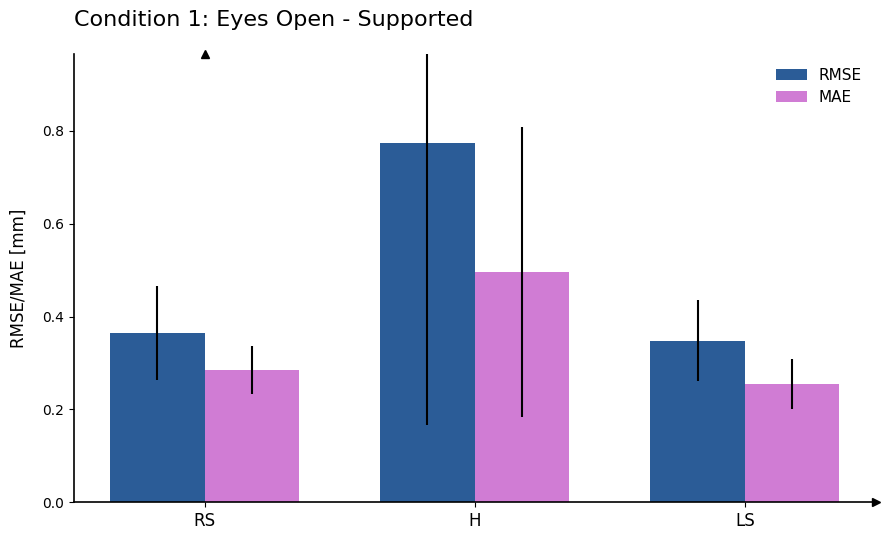

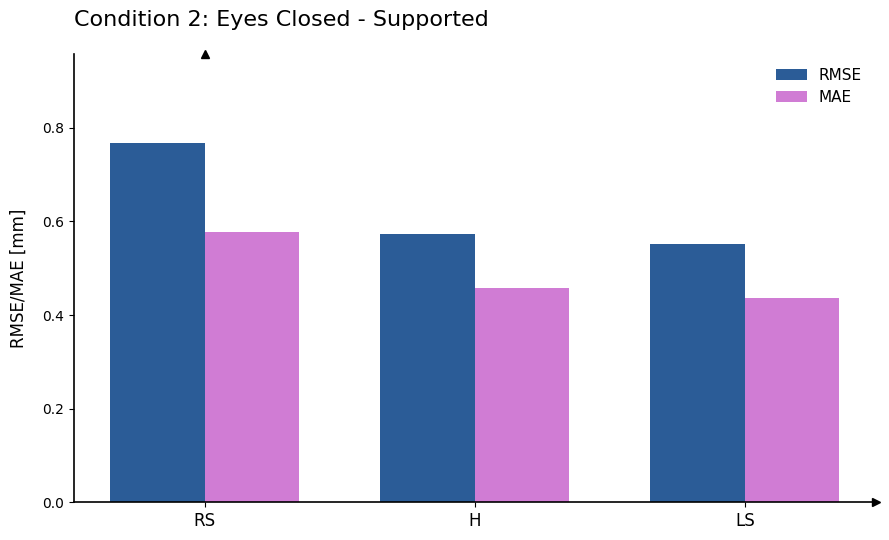

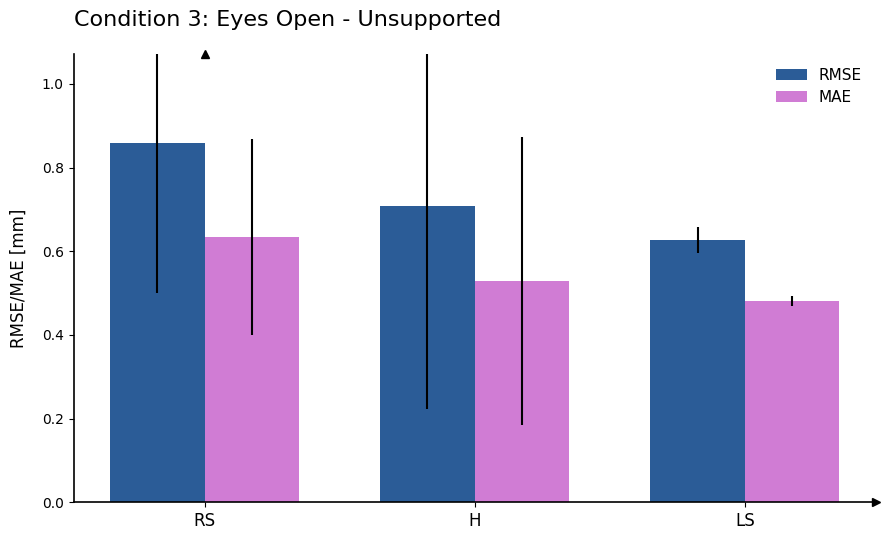

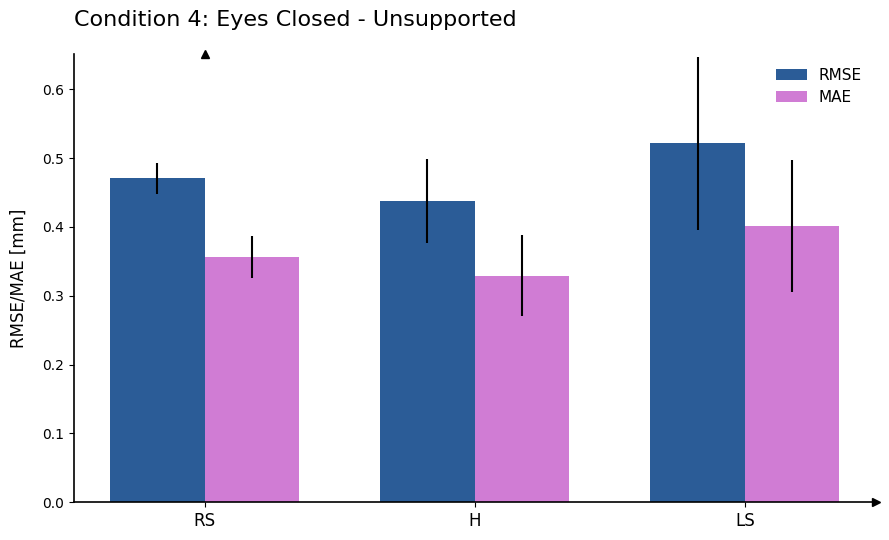

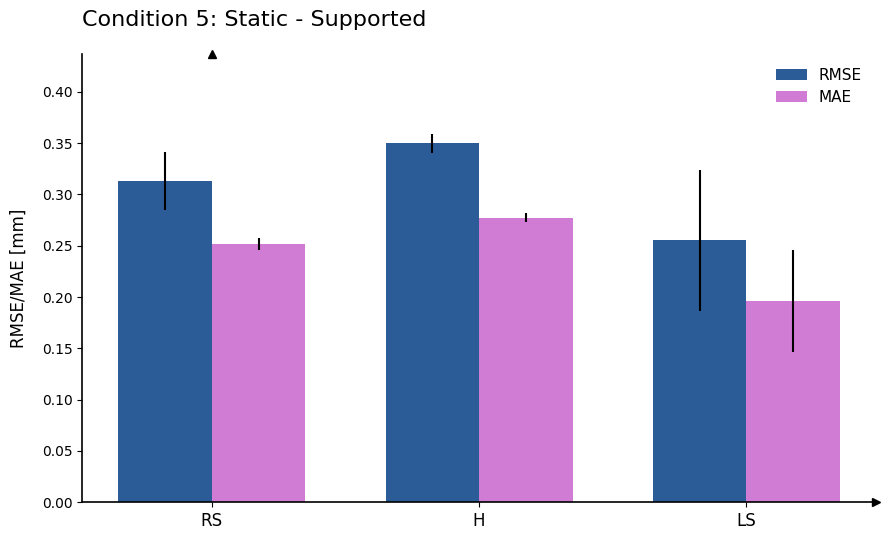

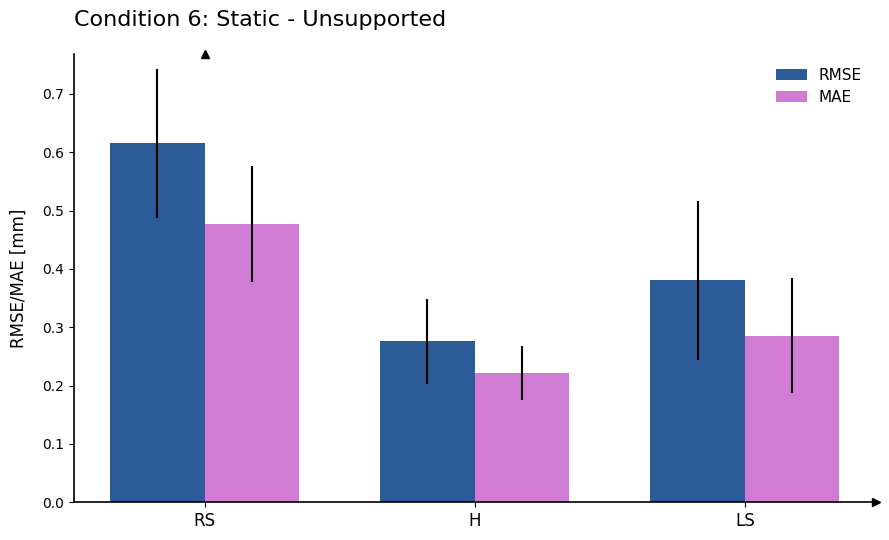

In [35]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. data introduced based on the results of the code above
data_records = [
    # EYES OPEN SUPPORTED
    {"Condition": 1, "Volunteer": "Mariona", "Position": "RS", "MAE": 0.3213, "RMSE": 0.4368},
    {"Condition": 1, "Volunteer": "Mariona", "Position": "H",  "MAE": 0.7165, "RMSE": 1.2017},
    {"Condition": 1, "Volunteer": "Mariona", "Position": "LS", "MAE": 0.2937, "RMSE": 0.4102},
    {"Condition": 1, "Volunteer": "Luca",    "Position": "RS", "MAE": 0.2474, "RMSE": 0.2933},
    {"Condition": 1, "Volunteer": "Luca",    "Position": "H",  "MAE": 0.2745, "RMSE": 0.3434},
    {"Condition": 1, "Volunteer": "Luca",    "Position": "LS", "MAE": 0.2173, "RMSE": 0.2862},

    # EYES CLOSED SUPPORTED
    {"Condition": 2, "Volunteer": "Luca",    "Position": "RS", "MAE": 0.5768, "RMSE": 0.7667},
    {"Condition": 2, "Volunteer": "Luca",    "Position": "H",  "MAE": 0.4575, "RMSE": 0.5722},
    {"Condition": 2, "Volunteer": "Luca",    "Position": "LS", "MAE": 0.4363, "RMSE": 0.5524},

    # EYES OPEN UNSUPPORTED
    {"Condition": 3, "Volunteer": "Mariona", "Position": "RS", "MAE": 0.4685, "RMSE": 0.6051},
    {"Condition": 3, "Volunteer": "Mariona", "Position": "H",  "MAE": 0.2860, "RMSE": 0.3653},
    {"Condition": 3, "Volunteer": "Mariona", "Position": "LS", "MAE": 0.4901, "RMSE": 0.6497},
    {"Condition": 3, "Volunteer": "Luca",    "Position": "RS", "MAE": 0.7997, "RMSE": 1.1102},
    {"Condition": 3, "Volunteer": "Luca",    "Position": "H",  "MAE": 0.7715, "RMSE": 1.0499},
    {"Condition": 3, "Volunteer": "Luca",    "Position": "LS", "MAE": 0.4724, "RMSE": 0.6053},

    # EYES CLOSED UNSUPPORTED
    {"Condition": 4, "Volunteer": "Mariona", "Position": "RS", "MAE": 0.3351, "RMSE": 0.4545},
    {"Condition": 4, "Volunteer": "Mariona", "Position": "H",  "MAE": 0.2875, "RMSE": 0.3943},
    {"Condition": 4, "Volunteer": "Mariona", "Position": "LS", "MAE": 0.4692, "RMSE": 0.6102},
    {"Condition": 4, "Volunteer": "Luca",    "Position": "RS", "MAE": 0.3774, "RMSE": 0.4868},
    {"Condition": 4, "Volunteer": "Luca",    "Position": "H",  "MAE": 0.3713, "RMSE": 0.4806},
    {"Condition": 4, "Volunteer": "Luca",    "Position": "LS", "MAE": 0.3336, "RMSE": 0.4322},

    # STATIC SUPPORTED
    {"Condition": 5, "Volunteer": "Mariona", "Position": "RS", "MAE": 0.2556, "RMSE": 0.3335},
    {"Condition": 5, "Volunteer": "Mariona", "Position": "H",  "MAE": 0.2804, "RMSE": 0.3560},
    {"Condition": 5, "Volunteer": "Mariona", "Position": "LS", "MAE": 0.2316, "RMSE": 0.3041},
    {"Condition": 5, "Volunteer": "Luca",    "Position": "RS", "MAE": 0.2474, "RMSE": 0.2933},
    {"Condition": 5, "Volunteer": "Luca",    "Position": "H",  "MAE": 0.2745, "RMSE": 0.3434},
    {"Condition": 5, "Volunteer": "Luca",    "Position": "LS", "MAE": 0.1613, "RMSE": 0.2064},

    # STATIC UNSUPPORTED
    {"Condition": 6, "Volunteer": "Mariona", "Position": "RS", "MAE": 0.4063, "RMSE": 0.5249},
    {"Condition": 6, "Volunteer": "Mariona", "Position": "H",  "MAE": 0.2542, "RMSE": 0.3277},
    {"Condition": 6, "Volunteer": "Mariona", "Position": "LS", "MAE": 0.3555, "RMSE": 0.4772},
    {"Condition": 6, "Volunteer": "Luca",    "Position": "RS", "MAE": 0.5472, "RMSE": 0.7054},
    {"Condition": 6, "Volunteer": "Luca",    "Position": "H",  "MAE": 0.1892, "RMSE": 0.2238},
    {"Condition": 6, "Volunteer": "Luca",    "Position": "LS", "MAE": 0.2157, "RMSE": 0.2844},
]

df = pd.DataFrame(data_records)

condition_titles = {
    1: "Eyes Open - Supported",
    2: "Eyes Closed - Supported",
    3: "Eyes Open - Unsupported",
    4: "Eyes Closed - Unsupported",
    5: "Static - Supported",
    6: "Static - Unsupported"
}

output_folder = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/r/Output_processed"
os.makedirs(output_folder, exist_ok=True)

# ---------------------------------------------------------------------------
# Generate graph for each condition
# ---------------------------------------------------------------------------
positions = ["RS", "H", "LS"]
width = 0.35
color_rmse = "#2b5c97"
color_mae = "#d07cd4"

for cond_id in sorted(df["Condition"].unique()):
    cond_df = df[df["Condition"] == cond_id]

    summary = cond_df.groupby("Position").agg(
        MAE_mean=("MAE", "mean"),
        MAE_std=("MAE", "std"),
        RMSE_mean=("RMSE", "mean"),
        RMSE_std=("RMSE", "std")
    ).reindex(positions)

    # Note: if one condition has only 1 volunteer (like the 2nd), the std will be Nan, so we put 0 to avoid visual problems
    summary = summary.fillna(0)

    fig, ax = plt.subplots(figsize=(9, 5.5))
    x = np.arange(len(positions))

    ax.bar(
        x - width/2, summary["RMSE_mean"], width,
        yerr=summary["RMSE_std"], label="RMSE",
        color=color_rmse, edgecolor="none", error_kw={"ecolor": "black", "linewidth": 1.5}
    )

    ax.bar(
        x + width/2, summary["MAE_mean"], width,
        yerr=summary["MAE_std"], label="MAE",
        color=color_mae, edgecolor="none", error_kw={"ecolor": "black", "linewidth": 1.5}
    )

    title_text = f"Condition {cond_id}: {condition_titles[cond_id]}"
    ax.set_title(title_text, fontsize=16, pad=20, fontweight="regular", loc="left")
    ax.set_ylabel("RMSE/MAE [mm]", fontsize=12, labelpad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(positions, fontsize=12)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.2)
    ax.spines["bottom"].set_linewidth(1.2)

    ax.plot(1, 0, ">k", transform=ax.get_yaxis_transform(), clip_on=False)
    ax.plot(0, 1, "^k", transform=ax.get_xaxis_transform(), clip_on=False)

    ax.legend(frameon=False, fontsize=11, loc="upper right")

    max_val = max(summary["RMSE_mean"].max(), summary["MAE_mean"].max())
    ax.set_ylim(0, max_val * 1.25)

    plt.tight_layout()

    file_name = f"comparison_condition_{cond_id}.png"
    save_path = os.path.join(output_folder, file_name)
    plt.savefig(save_path, dpi=300)

    plt.show()
    plt.close()